(20, 128)


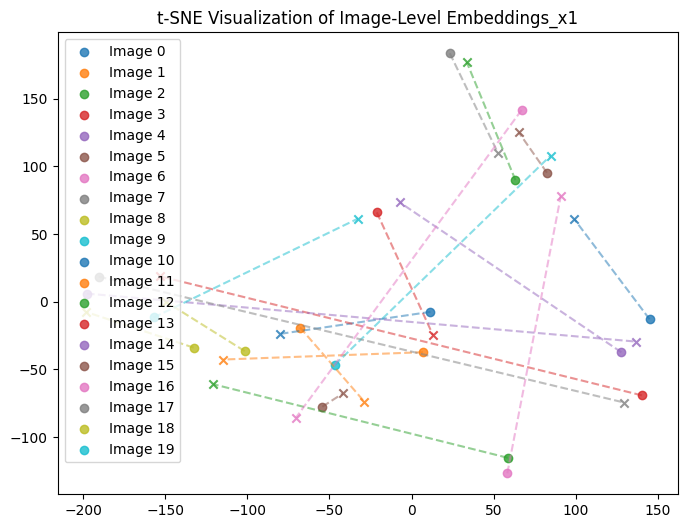

(20, 128)


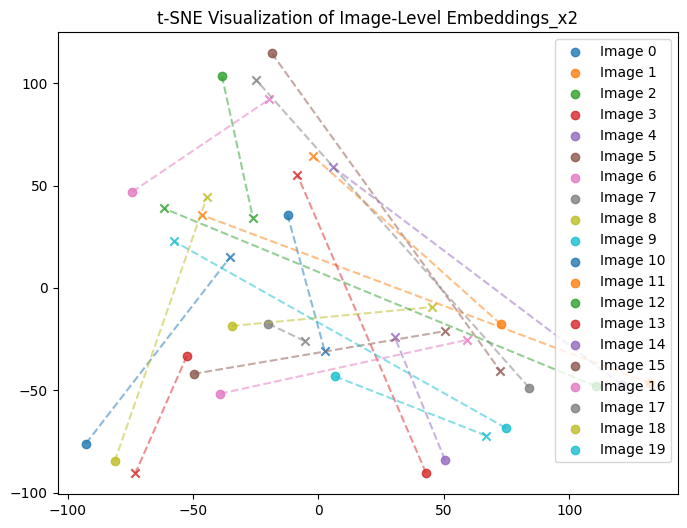

In [4]:
import torch

from src.self_supervised_learning.contrastive_loss import ContrastivePreTraining, visualize_tsne
from src.vision_transformer.model.two_scales import SemanticSegmentationVisionTransformer

model = SemanticSegmentationVisionTransformer(
    image_dims=(3, 128, 128),
    num_encoder_layers=4,
    decoder_type='lightweight',
    skip_layer_ratio=4,
    encoder_dropout_rate=0.25,
    patch_fusion_dropout_rate=0.25,
    decoder_dropout_rate=0.25,
    num_encoder_heads=4,
    num_classes=1,
    patch_embedding_scale_1=(16, 1024),
    patch_embedding_scale_2=(8, 768),
)
x = torch.rand(20, 3, 128, 128).float()

contrastive_model = ContrastivePreTraining(
    model=model,
    encoder_dims=[1024, 768],
    projection_dim=128,
)

visualize_tsne(contrastive_model, x)

In [45]:
output

tensor([[[[-60.1547, -60.1547, -60.1547,  ..., -23.6192, -23.6192, -23.6192],
          [-60.1547, -60.1547, -60.1547,  ..., -23.6192, -23.6192, -23.6192],
          [-60.1547, -60.1547, -60.1547,  ..., -23.6192, -23.6192, -23.6192],
          ...,
          [ -9.7661,  -9.7661,  -9.7661,  ..., -33.9507, -33.9507, -33.9507],
          [ -9.7661,  -9.7661,  -9.7661,  ..., -33.9507, -33.9507, -33.9507],
          [ -9.7661,  -9.7661,  -9.7661,  ..., -33.9507, -33.9507, -33.9507]]]],
       grad_fn=<ConvolutionBackward0>)

In [4]:
import torch as _torch
import torch.nn as _nn
import typing as _t


class PatchFusion(_nn.Module):
    """
    Patch fusion layer that will fuse the embeddings of the patches to a common scale.
    """

    def __init__(
            self, *, in_dims: _t.List[_t.List[int]], out_patches: int, out_embed: int, dropout_rate: float
    ) -> None:
        """

        :param in_dims: The dimensions of the input tensors.
        :param out_patches: The number of output patches.
        :param out_embed: The length of the output patch embeddings.
        :param dropout_rate: Dropout rate.
        """
        super(PatchFusion, self).__init__()

        out_resolution = int(out_patches ** 0.5)
        in_resolutions = []
        patch_embedding_projectors = _nn.ModuleList()
        for in_patches, in_embed in in_dims:
            in_resolution = int(in_patches ** 0.5)
            if in_patches < out_patches:
                scale = out_resolution // in_resolution
                operation = _nn.Sequential(
                    _nn.Conv2d(
                        in_channels=in_embed, out_channels=out_embed, kernel_size=1, stride=1
                    ),
                    _nn.Upsample(scale_factor=scale, mode="nearest")
                )
            elif in_patches > out_patches:
                scale = in_resolution // out_resolution
                operation = _nn.Conv2d(
                    in_channels=in_embed, out_channels=out_embed, kernel_size=scale, stride=scale
                )
            else:
                operation = _nn.Identity()

            patch_embedding_projectors.append(_nn.Sequential(
                operation,
                _nn.BatchNorm2d(out_embed),
                _nn.ReLU(),
                _nn.Dropout(dropout_rate)
            ))
            in_resolutions.append(in_resolution)

        self.__patch_embedding_projectors = patch_embedding_projectors
        self.__out_resolution = out_resolution
        self.__in_resolutions = in_resolutions
        self.__out_patches = out_patches
        self.__out_embed = out_embed
        self.__initialize_weights()

    def forward(self, target_tensor: _torch.Tensor, tensors: _t.List[_torch.Tensor]) -> _torch.Tensor:
        """
        Forward pass of the patch fusion layer to merge together a given tensor with a target tensor by modifying
        spatial dimension using learnable operations.

        :param target_tensor: Target tensor to be fused with. Shape (batch_size, out_patches, out_embed).
        :param tensors: List of tensors to be fused. Shape (batch_size, in_patches, in_embed).
        :return: Fused tensor. Shape (batch_size, out_patches, out_embed).
        """
        patch_embedding_projectors = self.__patch_embedding_projectors
        in_resolutions = self.__in_resolutions
        out_resolution = self.__out_resolution
        out_patches = self.__out_patches
        out_embed = self.__out_embed

        # Reshape the target tensor to (B, E, P, P)
        B, P, E = target_tensor.shape
        target_tensor = target_tensor.reshape(B, out_resolution, out_resolution, E).permute(0, 3, 1, 2).contiguous()

        # Apply the patch embedding projectors
        for tensor, projector, in_resolution in zip(tensors, patch_embedding_projectors, in_resolutions):
            B, P, E = tensor.shape
            tensor = tensor.reshape(B, in_resolution, in_resolution, E).permute(0, 3, 1, 2).contiguous()
            tensor = projector(tensor)
            target_tensor = target_tensor + tensor

        target_tensor = target_tensor.permute(0, 3, 1, 2).reshape(B, out_patches, out_embed).float()

        return target_tensor

    def __initialize_weights(self) -> None:
        """
        Initialize the weights of the patch fusion layer.
        """
        patch_embedding_projectors = self.__patch_embedding_projectors

        for projector in patch_embedding_projectors:
            for module in projector.modules():
                if isinstance(module, _nn.Conv2d):
                    _nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                    if module.bias is not None:
                        _nn.init.constant_(module.bias, 0)
                elif isinstance(module, _nn.BatchNorm2d):
                    _nn.init.constant_(module.weight, 1)
                    _nn.init.constant_(module.bias, 0)

In [5]:
import torch as _torch

patch_fusion = PatchFusion(
    in_dims=[[1024, 768], [4096, 512]],
    out_patches=256,
    out_embed=1024,
    dropout_rate=0.25,
)

target = _torch.randn(10, 256, 1024)
x1 = _torch.randn(10, 1024, 768)
x2 = _torch.randn(10, 4096, 512)

y = patch_fusion(target_tensor=target, tensors=[x1, x2])
y.shape

torch.Size([10, 256, 1024])